# GLM-HMM fit to data

Notebook to fit the GLM-HMM from Ashwood et al. (2020) ([Mice alternate between discrete strategies during perceptual decision-making](https://www.nature.com/articles/s41593-021-01007-z)).

Based on the example notebook [2b Input Driven Observations (GLM-HMM)](https://github.com/zashwood/ssm/blob/master/notebooks/2b%20Input%20Driven%20Observations%20(GLM-HMM).ipynb).

The logic of the original notebook is to simulate synthetic data with a generative GLM-HMM, fit a GLM-HMM to the synthetic data, and check that we can recover the generative parameters. Following that tutorial, we will use real data from the 2AFC task instead of generating synthetic one, fit a GLM-HMM to it and recover the parameters. Easy peasy, lemon squeezy!

## 1. Setup
The line `import ssm` imports the package for use. Here, we have also imported a few other packages for plotting.

In [1]:
import pandas as pd
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
import ssm
from ssm.util import find_permutation

npr.seed(0)

## 2. Input Driven Observations
We create a HMM with input-driven observations and 'standard' (stationary) transitions with the following line:
```python
        ssm.HMM(num_states, obs_dim, input_dim, observations="input_driven_obs", observation_kwargs=dict(C=num_categories), transitions="standard")
```

As in Ashwood et al. (2020), we are going to model an animal's binary choice data during a decision-making task, so we will set `num_categories=2` because the animal only has two options available to it. We will also set `obs_dim = 1` because the dimensionality of the observation data is 1 (if we were also modeling, for example, the binned reaction time of the animal, we could set `obs_dim = 2`).  For the sake of simplicity, we will assume that an animal's choice in a particular state is only affected by the external stimulus associated with that particular trial, and its innate choice bias. Thus, we will set `input_dim = 2` and we will simulate input data that resembles sequences of stimuli in what follows.  In Ashwood et al. (2020), they found that many mice used 3 decision-making states when performing 2AFC tasks. We will, thus, set `num_states = 3`.

## 3. Fit GLM-HMM and perform recovery analysis

Instead of generating data, we will use real data from my the 2AFC task.

In [25]:
# Load data from example mouse
df = pd.read_csv(r'C:\Users\Usuario\PycharmProjects\glue_sessions\2AFC_2\333.csv')

# Load intersession data
df_intersession = pd.read_csv(r'C:\Users\Usuario\PycharmProjects\intersession\2AFC_2\333_intersession.csv')
df_intersession = df_intersession[df_intersession.P==0.5].reset_index(drop=True)  # Keep only P=0.5 trials

# Find the date with max accuracy
# max_date = df_intersession.loc[df_intersession['Accuracy'].idxmax(), 'Dates']
# print(max_date)

# Filters for groups 1-3
df = df[df.Stage == 4].reset_index(drop=True)
df = df[df.Motor == 4].reset_index(drop=True)
# df = df[df.StimDur == 1].reset_index(drop=True)
df = df[df.P > 0].reset_index(drop=True)

# # Keep only one session
# df = df[df.Date == max_date].reset_index(drop=True)  # Use the date with max accuracy
# df = df[df.Date == '2024-06-24']  007 ephys

# Drop misses (Choice == NaN)
df = df.dropna(subset=['Choice']).reset_index(drop=True)

C:\Users\Usuario\anaconda3\envs\glmhmm\lib\site-packages\IPython\core\interactiveshell.py:3258: DtypeWarning: Columns (24) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


To prepare the data for the GLM-HMM, we need to organize both the inputs (external covariates) and the choices (observations) **as lists of arrays, one per session**.

In this example, `df` contains the data from one or multiple sessions concatenated.

- **Inputs**: For each session, we create a 2D array of shape $(N_i, D)$, where $N_i$ is the number of trials in that session and $D=2$ is the number of input dimensions. Here, the two columns are:
  1. `df.ILD.values` — the stimulus presented on each trial
  2. A constant column of 1s — to capture the animal's baseline bias
- **Choices**: For each session, we create a 2D array of shape $(N_i, 1)$, where $N_i$ is the number of trials in that session. This array contains the animal's choices (0 or 1) for each trial.

In [33]:
# Define a function to parse the data for GLM-HMM
def parse_glmhmm(df):
    """
    Parse the data for GLM-HMM.
    :param df: DataFrame containing the data (one or many sessions concatenated).
    :return: inputs, choices
    """

    inputs = []
    choices = []

    for session_id, df_session in df.groupby('Session'):
        n_trials = len(df_session)
        session_input = np.column_stack((df_session.ILD.values, np.ones(n_trials)))
        inputs.append(session_input)
        choices.append(df_session.Choice.values.astype(int)[:, None])

    return inputs, choices

# Parse the data
inputs, choices = parse_glmhmm(df)

### Initialize GLM-HMM (2a)

In [35]:
# Set the parameters of the GLM-HMM
num_states = 3        # number of discrete states (from Ashwood et al. 2020)
obs_dim = 1           # number of observed dimensions (1 for binary choice)
num_categories = 2    # number of categories for output (2 for binary choice)
input_dim = 2         # input dimensions (stimulus and bias)

glmhmm = ssm.HMM(num_states, obs_dim, input_dim, observations="input_driven_obs",
                   observation_kwargs=dict(C=num_categories), transitions="standard")

Check data has correct format and shape

In [45]:
# Check types
assert isinstance(inputs, list), 'Inputs should be a list'
assert isinstance(choices, list), 'Choices should be a list'

# Check shapes per session
for session_input, session_choice in zip(inputs, choices):
    assert session_input.shape[0] == session_choice.shape[0], "Each session input and choice should have the same number of trials"
    assert session_input.shape[1] == input_dim, f"Each session input should have {input_dim} columns"
    assert session_choice.shape[1] == obs_dim, f"Each session choice should have {obs_dim} columns"

### 3a. Maximum Likelihood Estimation

In [37]:
N_iters = 200 # maximum number of EM iterations. Fitting with stop earlier if increase in LL is below tolerance specified by tolerance parameter
fit_ll = glmhmm.fit(choices, inputs=inputs, method="em", num_iters=N_iters, tolerance=10**-4)

C:\Users\Usuario\ssm\ssm\optimizers.py:146: UserWarning: BFGS failed with message:
Desired error not necessarily achieved due to precision loss.
  warn("{} failed with message:\n{}".format(method, result.message))


  0%|          | 0/200 [00:00<?, ?it/s]

C:\Users\Usuario\ssm\ssm\optimizers.py:146: UserWarning: BFGS failed with message:
Desired error not necessarily achieved due to precision loss.
  warn("{} failed with message:\n{}".format(method, result.message))
C:\Users\Usuario\ssm\ssm\optimizers.py:146: UserWarning: BFGS failed with message:
Desired error not necessarily achieved due to precision loss.
  warn("{} failed with message:\n{}".format(method, result.message))
C:\Users\Usuario\ssm\ssm\optimizers.py:146: UserWarning: BFGS failed with message:
Desired error not necessarily achieved due to precision loss.
  warn("{} failed with message:\n{}".format(method, result.message))
C:\Users\Usuario\ssm\ssm\optimizers.py:146: UserWarning: BFGS failed with message:
Desired error not necessarily achieved due to precision loss.
  warn("{} failed with message:\n{}".format(method, result.message))
C:\Users\Usuario\ssm\ssm\optimizers.py:146: UserWarning: BFGS failed with message:
Desired error not necessarily achieved due to precision loss.

Text(0, 0.5, 'Log Probability')

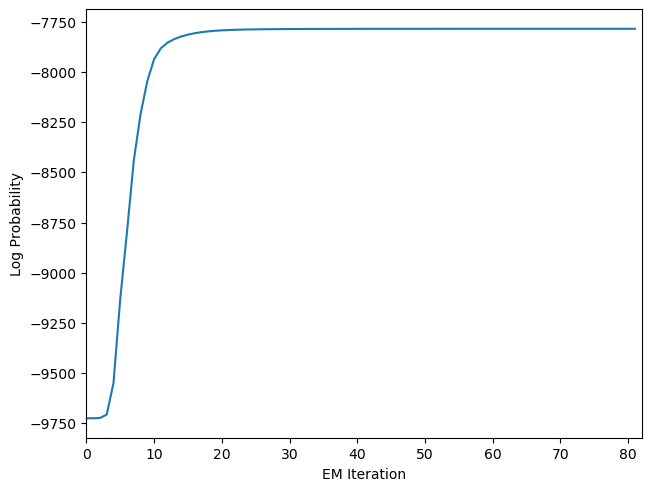

In [48]:
# Plot the log probabilities of the fit model
plt.figure(constrained_layout=True)
plt.plot(fit_ll)
plt.xlabel('EM Iteration')
plt.xlim(0, len(fit_ll))
plt.ylabel('Log Probability')

### 3b. Retrieved parameters

In [53]:
weights = new_glmhmm.observations.params
trans_mat = new_glmhmm.transitions.transition_matrix

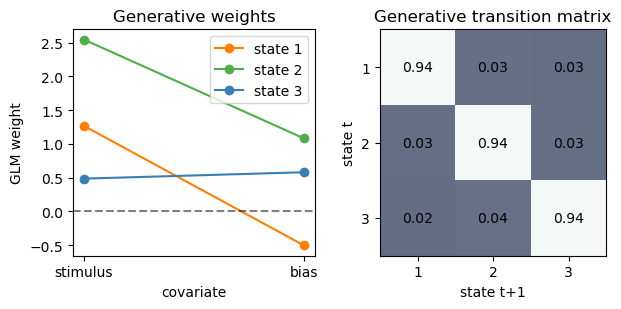

In [65]:
# Get default figsize
default_figsize = plt.rcParams['figure.figsize']

# Plot generative parameters:
fig = plt.figure(figsize=(default_figsize[0], default_figsize[0]/2))
plt.subplot(1, 2, 1)
cols = ['#ff7f00', '#4daf4a', '#377eb8']
for k in range(num_states):
    plt.plot(range(input_dim), weights[k][0], marker='o', color=cols[k], linestyle='-', lw=1.5, label="state " + str(k+1))
plt.yticks()
plt.ylabel("GLM weight")
plt.xlabel("covariate")
plt.xticks([0, 1], ['stimulus', 'bias'])
plt.axhline(y=0, color="k", alpha=0.5, ls="--")
plt.legend()
plt.title("Generative weights")

plt.subplot(1, 2, 2)
# gen_trans_mat = np.exp(log_trans_mat)[0]
plt.imshow(trans_mat, vmin=-0.8, vmax=1, cmap='bone')
for i in range(trans_mat.shape[0]):
    for j in range(trans_mat.shape[1]):
        text = plt.text(j, i, str(np.around(trans_mat[i, j], decimals=2)), ha="center", va="center",
                        color="k")
plt.xlim(-0.5, num_states - 0.5)
plt.xticks(range(0, num_states), ('1', '2', '3'))
plt.yticks(range(0, num_states), ('1', '2', '3'))
plt.ylim(num_states - 0.5, -0.5)
plt.ylabel("state t")
plt.xlabel("state t+1")
plt.title("Generative transition matrix")

plt.tight_layout()

### 3c. Posterior State Probabilities

In [67]:
# Get expected states:
posterior_probs = [glmhmm.expected_states(data=data, input=inpt)[0]
                for data, inpt
                in zip(choices, inputs)]

Text(0, 0.5, 'p(state)')

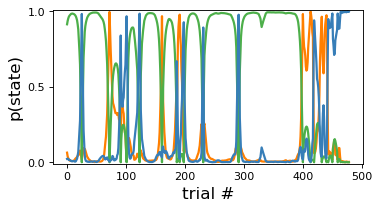

In [68]:
fig = plt.figure(figsize=(5, 2.5), dpi=80, facecolor='w', edgecolor='k')
sess_id = 0 #session id; can choose any index between 0 and num_sess-1
for k in range(num_states):
    plt.plot(posterior_probs[sess_id][:, k], label="State " + str(k + 1), lw=2,
             color=cols[k])
plt.ylim((-0.01, 1.01))
plt.yticks([0, 0.5, 1], fontsize = 10)
plt.xlabel("trial #", fontsize = 15)
plt.ylabel("p(state)", fontsize = 15)